### Data Exploration, Cleaning, and sample comparisons.  

In [ ]:
# Import needed libraries and check current working directory. 
import os
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.weightstats import ttest_ind as sm_ttest
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt
os.getcwd()

### Two sample t-test

We will use data from the Palmer Penguins dataset to explore how to compare two means. This data contains body measurements for 344 penguins of three species, collected at the Palmer Station Long Term Ecological Research site in Antarctica. 

Note: There is a Palmer Penguins package that is available in Python and you can install and manage it as part of your environment. This is optional and you do not have to do this. I've downloaded this dataset and put it in the data folder since that is how we will mostly do things going forward.  

In [ ]:
# First, we always want to pull the data and take a look at it. 

peng = pd.read_csv("../data/penguins.csv")
print(peng.shape)
peng.head()

In [ ]:
# The first question we want to ask is:
# Is there an appreciable difference in body mass between male and female penguins. 

# There is some missing data above. Let's explore this a bit more. 
print(peng.isna().sum())
print()
print(peng["sex"].value_counts(dropna=False))


In [ ]:
# First, let's visualize this data before computing a T-test

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=peng.dropna(subset=["sex"]),
    x="sex",
    y="body_mass_g",
    hue="sex",
    palette="Set2",
    legend=False
)
plt.xlabel("")
plt.ylabel("body mass (g)")
plt.title("Body mass by sex")
plt.show()

In [ ]:
# There are 11 penguins where we don't know if they are male or female, so we'll drop those
# from our analysis. 

# First we want to compute mean male and female body masses, and use the scipy stats package to compute a t-test. 

male_mass = peng.loc[peng["sex"] == "male", "body_mass_g"].dropna()
female_mass = peng.loc[peng["sex"] == "female", "body_mass_g"].dropna()

# Note that we are assuming our measurements do not have equal variance. 
t_stat, p_value = stats.ttest_ind(male_mass, female_mass, equal_var=False)

print("mean body mass, male:  ", round(male_mass.mean(), 1), " n =", len(male_mass))
print("mean body mass, female:", round(female_mass.mean(), 1), " n =", len(female_mass))
print("t-statistic:", round(t_stat, 3))
print("p-value:", p_value)


In [ ]:
# Note that we could also use the statsmodels package to do this calculation. 
# Note that the arguments are different and there is an additional return variable but the result is the same

t_stat, p_value, df = sm_ttest(male_mass, female_mass, usevar='unequal')

print("mean body mass, male:  ", round(male_mass.mean(), 1), " n =", len(male_mass))
print("mean body mass, female:", round(female_mass.mean(), 1), " n =", len(female_mass))
print("t-statistic:", round(t_stat, 3))
print("p-value:", p_value)

In [ ]:
# We just looked at whether body mass would vary significantly between males and females.
# Now let's look at whether body mass varies significantly between Adelie and Chinstrap penguins. 
# We are going to ignore Gentoo for the moment.

# First, let's plot this to get a visual. 

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=peng.dropna(subset=["species"]),
    x="species",
    y="body_mass_g",
    hue="species",
    palette="Set2",
    legend=False
)
plt.xlabel("Species")
plt.ylabel("body mass (g)")
plt.show()

In [ ]:
# Now let's do a t-test 

adelie = peng.loc[peng["species"] == "Adelie", "body_mass_g"].dropna()
chinstrap = peng.loc[peng["species"] == "Chinstrap", "body_mass_g"].dropna()

t_stat, p_value = stats.ttest_ind(adelie, chinstrap, equal_var=False)

print("   Adelie:   ", round(adelie.mean(), 1))
print("   Chinstrap:", round(chinstrap.mean(), 1))
print("   t =", round(t_stat, 3), "  p =", p_value)
print()

### Analysis of Variance

Now let's look at comparing more than one mean using ANOVA. 

In [ ]:
# Let's check the equal variance assumption looking at body mass
peng_anova = peng.dropna(subset=["body_mass_g", "species"])
print(peng_anova.groupby("species")["body_mass_g"].agg(["count", "mean", "std"]).round(2))

groups = [peng_anova.loc[peng_anova["species"] == s, "body_mass_g"]
          for s in ["Adelie", "Chinstrap", "Gentoo"]]

print("Levene's test p-value:", round(stats.levene(*groups).pvalue, 4))

In [ ]:
# Equal variance is violated (e.g. the p-value indicates the null hypothesis--equal variance--is reqjected)
# This means that ANOVA is not appropriate here.

# Let's instead at a different variable, bill depth. 

peng_anova = peng.dropna(subset=["bill_depth_mm", "species"])
print(peng_anova.groupby("species")["bill_depth_mm"].agg(["count", "mean", "std"]).round(2))

groups = [peng_anova.loc[peng_anova["species"] == s, "bill_depth_mm"]
          for s in ["Adelie", "Chinstrap", "Gentoo"]]

print("Levene's test p-value:", round(stats.levene(*groups).pvalue, 4))

In [ ]:
# The null hypothesis (equal variance) is supported. Let's do the ANOVA

model = ols("bill_depth_mm ~ C(species)", data=peng_anova).fit()
print(sm.stats.anova_lm(model, typ=2))

# What does this result tell us? 

In [ ]:
# Now let's plot bill depth as a function of species. 

plt.figure(figsize=(6, 4))
sns.boxplot(data=peng_anova, x="species", y="bill_depth_mm",
            hue="species", palette="Set2", legend=False)
plt.ylabel("bill depth (mm)")
plt.title("Bill depth by species")
plt.show()

In [ ]:
# TukeyHSD

tukey_result = pairwise_tukeyhsd(peng_anova["bill_depth_mm"], peng_anova["species"], alpha=0.05)
print(tukey_result)

In [ ]:
# Visualize the Tukey HSD results

# Convert Tukey HSD results to a DataFrame
tukey_df = pd.DataFrame(
    data=tukey_result._results_table.data[1:],
    columns=tukey_result._results_table.data[0]
)
tukey_df["comparison"] = tukey_df["group1"] + " – " + tukey_df["group2"]

fig, ax = plt.subplots(figsize=(7, 4))

sig_color = "#d03b3b"      # significant (reject H0)
nonsig_color = "#898781"   # not significant

colors = tukey_df["reject"].map({True: sig_color, False: nonsig_color})

for i, row in tukey_df.iloc[::-1].reset_index(drop=True).iterrows():
    color = sig_color if row["reject"] else nonsig_color
    ax.plot(
        [row["lower"], row["upper"]], [i, i],
        color=color, linewidth=2, solid_capstyle="round"
    )
    ax.plot(row["meandiff"], i, "o", color=color, markersize=6)

ax.axvline(0, color="#c3c2b7", linewidth=1, linestyle="--")
ax.set_yticks(range(len(tukey_df)))
ax.set_yticklabels(tukey_df["comparison"][::-1])
ax.set_xlabel("Mean difference in Bill Depth")
ax.set_title("Tukey HSD: pairwise comparisons (95% CI)")

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)

plt.tight_layout()
plt.show()

### Exploring Class Data

Let's take some of the concepts we learned above and apply them to our class data. 

In [3]:
# Read in data frame and look at first few rows
import pandas as pd
df = pd.read_csv('../data/DS6021-Fall26-Anonymized.csv')
df.head()

,Timestamp,What was your undergraduate major?,What type of phone do you have?,How many years ago did you receive your undergraduate degree?,How many hours do you sleep in a typical night?,Rate your proficiency with git/github,Rate your proficiency with Python,Have you ever used SQL?,What is your favorite sport to watch on tv?,What is your ideal outdoor temperature (in Fahrenheit)?,How many US states have you visited?,What is your favorite season?
0,8/25/2026 8:20:43,Psychology,iPhone,4-6 years,8,3,2,Yes,F1 motorsport,70,8,Fall
1,8/25/2026 9:35:51,Statistics,iPhone,1-3 years,8,3,4,Yes,NaN,70,16,Fall
2,8/25/2026 13:43:23,Economics-Business and Applied Mathematics,iPhone,< 1 year,8,3,3,No,Baseball,70,27,Fall
3,8/25/2026 15:11:38,Data Science (concentration in Computer Science),iPhone,< 1 year,8,3,4,Yes,Football (go Bears!),73,9,Fall
4,8/25/2026 15:26:11,Math and Physics,iPhone,1-3 years,8,2,4,Yes,Figure Skating,73,26,Fall


In [4]:
# Let's look at number of hours slept per night vs time in undergrad. 
# First we are going to rename the columns to something more manageable

df_sleep = df[[
    "How many years ago did you receive your undergraduate degree?",
    "How many hours do you sleep in a typical night?"
]].rename(columns={
    "How many years ago did you receive your undergraduate degree?": "years_since_undergrad",
    "How many hours do you sleep in a typical night?": "sleep_hrs"
})

df_sleep.head()

,years_since_undergrad,sleep_hrs
0,4-6 years,8
1,1-3 years,8
2,< 1 year,8
3,< 1 year,8
4,1-3 years,8


In [5]:
df_sleep["sleep_hrs"].unique()

array(['8', '7', '6-7', '9', '5', '8-9', '6-8', '7-9',
       '4-5 if I am lucky, I’m a diagnosed insomniac ', '8 to 9', '7.5',
       '6', '5.5', '6-10', '7-8', '6 hours', '8-9.5', '8-10', '8.5',
       '7ish', '0 to 8 hours', 'about 7 sometimes 8', '7 to 8', '8.25',
       '6-7 hours', '5-7', '4 - 6', '6.5'], dtype=object)

In [6]:
# Let's clean up sleep hours and properly categorize years since undergrad.
year_order = ["< 1 year", "1-3 years", "4-6 years", "7-10 years", "10+ years"]
df_sleep["years_since_undergrad"] = pd.Categorical(
    df_sleep["years_since_undergrad"], categories=year_order, ordered=True
)

# Average the first two numbers in each response: '6-7' -> 6.5, 'about 7 sometimes 8' -> 7.5
# Note: This is an example of the types of assumptions I wanted you to think through in Lab 0. 
bounds = df_sleep["sleep_hrs"].str.extractall(r"(\d+\.?\d*)")[0].astype(float)
df_sleep["sleep_hrs"] = bounds.groupby(level=0).agg(lambda x: x.head(2).mean())

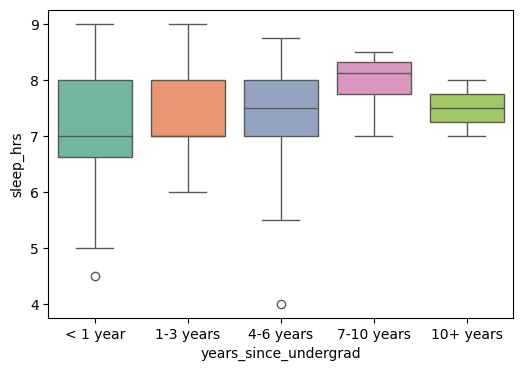

In [9]:
# Now let's plot number of hours of sleep as a function of years since undergrad

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df_sleep,
    x="years_since_undergrad",
    y="sleep_hrs",
    hue="years_since_undergrad",
    palette="Set2"
)

plt.xlabel("years_since_undergrad")
plt.ylabel("sleep_hrs")
plt.show()

In [10]:
# Now we want to look at favorite season and ideal temperature

# First let's subset the dataframe to look at just those two columns. 
# We will also rename the columns to something less unwieldy. 

df_subset = df[[
    "What is your favorite season?",
    "What is your ideal outdoor temperature (in Fahrenheit)?"
]].rename(columns={
    "What is your favorite season?": "fav_season",
    "What is your ideal outdoor temperature (in Fahrenheit)?": "ideal_temp"
})

df_subset.head()

,fav_season,ideal_temp
0,Fall,70
1,Fall,70
2,Fall,70
3,Fall,73
4,Fall,73


In [11]:
# Let's explore and clean the dataset a little bit

df_subset["ideal_temp"].describe()

count     86
unique    30
top       70
freq      12
Name: ideal_temp, dtype: object

In [12]:
df_subset["ideal_temp"].unique()

array(['70', '73', '70 degrees', '55', '64', '75', '68', '65', '70-85',
       '78', '80', '85', '74', '72', '63 degrees', '77', '76', "70's",
       '71', '57', '79', 'High sixties', '40', '67', '60',
       '75 slightly sunny', '75 F', "Mid 70's", '40 degrees', '63'],
      dtype=object)

In [13]:
# We can make a couple of different assumptions about the data.
# You might have chosen differently, I'm going to do the following mappings:

word_to_number = {
    "High sixties": 68,
    "Mid 70's": 75,
    "70-85": 77
}

# I will then remove all non-numeric values from the remaining variables and convert this to a float. 

df_subset["ideal_temp"] = (
    df_subset["ideal_temp"]
    .replace(word_to_number)
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

df_subset["ideal_temp"].unique()

array([70., 73., 55., 64., 75., 68., 65., 77., 78., 80., 85., 74., 72.,
       63., 76., 71., 57., 79., 40., 67., 60.])

In [14]:
df_subset["ideal_temp"].describe()

count    86.000000
mean     70.197674
std       7.319305
min      40.000000
25%      68.000000
50%      70.000000
75%      75.000000
max      85.000000
Name: ideal_temp, dtype: float64

In [15]:
df_subset["fav_season"].value_counts()

fav_season
Fall      42
Spring    23
Summer    13
Winter     8
Name: count, dtype: int64

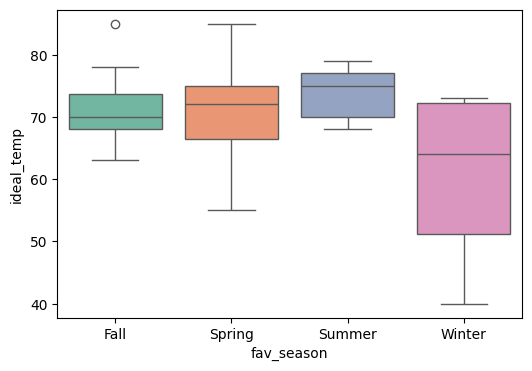

In [16]:
# Now let's plot favorite season and ideal temperature


plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df_subset,
    x="fav_season",
    y="ideal_temp",
    hue="fav_season",
    palette="Set2"
)

plt.xlabel("fav_season")
plt.ylabel("ideal_temp")
plt.show()

In [20]:
#...and conduct and analysis of variance (ANOVA) to see if there is a significant difference in ideal temperature across the different favorite seasons.
from statsmodels.formula.api import ols
import statsmodels.api as sm

model = ols("ideal_temp ~ C(fav_season)", data=df_subset).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
# The ANOVA shows a significant result, but why do we have to be careful interpreting the Tukey test below? 

tukey_result = pairwise_tukeyhsd(
    endog=df_subset["ideal_temp"],
    groups=df_subset["fav_season"],
    alpha=0.05
)

print(tukey_result)

# Note: From the plot above, we see that the equal-variance assumption is not supported. 

In [ ]:
# Visualize the Tukey HSD results - but again, we take them with a large grain of salt since equal-variance is not true. 

# Convert Tukey HSD results to a DataFrame
tukey_df = pd.DataFrame(
    data=tukey_result._results_table.data[1:],
    columns=tukey_result._results_table.data[0]
)
tukey_df["comparison"] = tukey_df["group1"] + " – " + tukey_df["group2"]

fig, ax = plt.subplots(figsize=(7, 4))

sig_color = "#d03b3b"      # significant (reject H0)
nonsig_color = "#898781"   # not significant

colors = tukey_df["reject"].map({True: sig_color, False: nonsig_color})

for i, row in tukey_df.iloc[::-1].reset_index(drop=True).iterrows():
    color = sig_color if row["reject"] else nonsig_color
    ax.plot(
        [row["lower"], row["upper"]], [i, i],
        color=color, linewidth=2, solid_capstyle="round"
    )
    ax.plot(row["meandiff"], i, "o", color=color, markersize=6)

ax.axvline(0, color="#c3c2b7", linewidth=1, linestyle="--")
ax.set_yticks(range(len(tukey_df)))
ax.set_yticklabels(tukey_df["comparison"][::-1])
ax.set_xlabel("Mean difference in ideal_temp")
ax.set_title("Tukey HSD: pairwise comparisons (95% CI)")

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8)

plt.tight_layout()
plt.show()